<a href="https://colab.research.google.com/github/jhenningsen/Equity_Analysis/blob/main/Misc/IPO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IPO Performance Analysis Notebook

This notebook performs an analysis of Initial Public Offering (IPO) performance based on historical stock data. It covers several key aspects:

*   **Data Loading and Merging**: Loads IPO data from multiple years (2024, 2025, 2026) and consolidates it into a single DataFrame, incorporating 'Deal Size' information.
*   **First Trading Day Identification**: Determines the actual first trading day for each IPO after its official IPO date, accounting for non-trading days.
*   **Return Calculation (Adjusted Close)**: Calculates 1, 3, 5, 10, 20, and 30-day returns based on the adjusted closing price of the first trading day for a filtered subset of IPOs (those with 'Deal Size' in billions).
*   **Summary Statistics (Adjusted Close)**: Provides average return, median return, and win rate for the returns calculated based on adjusted close.
*   **Return Calculation (IPO Price)**: Recalculates the same set of returns, but this time using the original IPO price as the base, offering a different perspective on performance relative to the initial offering price.
*   **Summary Statistics (IPO Price)**: Presents summary statistics for returns calculated from the IPO price.
*   **Day of Maximum Closing Price Analysis**: Identifies the trading day (within the first 30 days) when each IPO reached its maximum closing price.
*   **Distribution Visualization**: Displays histograms to visualize the distribution of these peak days, first for the filtered subset of IPOs, and then for all available IPOs in the dataset.

In [6]:
import json
import time
import io
import requests
import pandas as pd
import yfinance as yf
from datetime import timedelta

### Loading and Merging 'IPO Deal Size' Data

Now, let's load the provided `IPO_Deal_Size.csv` file and merge its information (Deal Size) into our `consolidated_df`. We will assume the 'Symbol' column is present in both DataFrames for the merge operation.

In [2]:
# These are Google Drive file IDs. To get your own, right-click on the file in Google Drive, select 'Share', then 'Get link'. The ID is the part of the URL after 'id='.
IPO_2024_FileId = '1CiGIOc7Z3Td4xTCICy7H3cF0QBIeUFiu'
IPO_2024_File = f'https://drive.google.com/uc?export=download&id={IPO_2024_FileId}'
# Load the IPO_Deal_Size.txt file as a pipe-separated file, handling quoted fields
ipo_2024_df = pd.read_csv(IPO_2024_File, sep=',', quotechar='"', skipinitialspace=True)

IPO_2025_FileId = '1uSI7gY4uKACxZqipBj3SefHSouAaNfrr'
IPO_2025_File = f'https://drive.google.com/uc?export=download&id={IPO_2025_FileId}'
# Load the IPO_Deal_Size.txt file as a pipe-separated file, handling quoted fields
ipo_2025_df = pd.read_csv(IPO_2025_File, sep=',', quotechar='"', skipinitialspace=True)

IPO_2026_FileId = '1XjCKzN_pXzoawIGpFqQs2iAtdBOBbvJC'
IPO_2026_File = f'https://drive.google.com/uc?export=download&id={IPO_2026_FileId}'
# Load the IPO_Deal_Size.txt file as a pipe-separated file, handling quoted fields
ipo_2026_df = pd.read_csv(IPO_2026_File, sep=',', quotechar='"', skipinitialspace=True)

In [3]:
# Concatenate the three IPO DataFrames into a single DataFrame
consolidated_df_with_deal_size = pd.concat([ipo_2024_df, ipo_2025_df, ipo_2026_df], ignore_index=True)

print("--- Consolidated DataFrame with Deal Size (Head) ---")
display(consolidated_df_with_deal_size.head())

print("--- Consolidated DataFrame with Deal Size (Tail) ---")
display(consolidated_df_with_deal_size.tail())

print("\nMerge complete. The `consolidated_df_with_deal_size` DataFrame now includes IPO data from 2024, 2025, and 2026.")

--- Consolidated DataFrame with Deal Size (Head) ---


,IPO Date,Symbol,Company Name,Current,Return,Exchange,Deal Size,Shares Offered,IPO Price
0,"Dec 31, 2024",ONEG,OneConstruction Group Limited,$1.20,-71.00%,NASDAQ,7.00M,"1,750,000",$4.00
1,"Dec 27, 2024",BYAH,"Park Ha Biological Technology Co., Ltd.",$0.435,-,NASDAQ,-,-,-
2,"Dec 23, 2024",HIT,"Health In Tech, Inc.",$1.03,-73.50%,NASDAQ,9.20M,"2,300,000",$4.00
3,"Dec 23, 2024",TDAC,Translational Development Acquisition Corp.,$10.70,7.00%,NASDAQ,150.00M,"15,000,000",$10.00
4,"Dec 20, 2024",RANG,Range Capital Acquisition Corp.,$10.67,6.70%,NASDAQ,100.00M,"10,000,000",$10.00


--- Consolidated DataFrame with Deal Size (Tail) ---


,IPO Date,Symbol,Company Name,Current,Return,Exchange,Deal Size,Shares Offered,IPO Price
766,"Jan 8, 2026",BBCQ,Bleichroeder Acquisition Corp. II,$10.32,3.20%,NASDAQ,250.00M,"25,000,000",$10.00
767,"Jan 8, 2026",BUDA,"Buda Juice, Inc.",$10.80,43.20%,NYSEAMERICAN,20.00M,"2,666,667",$7.50
768,"Jan 7, 2026",SORN,Soren Acquisition Corp.,$9.94,-0.60%,NASDAQ,220.00M,"22,000,000",$10.00
769,"Jan 6, 2026",ARTC,Art Technology Acquisition Corp.,$9.98,-0.20%,NASDAQ,220.00M,"22,000,000",$10.00
770,"Jan 6, 2026",BIII,Black Spade Acquisition III Co,$9.94,-0.40%,NYSE,150.00M,"15,000,000",$10.00



Merge complete. The `consolidated_df_with_deal_size` DataFrame now includes IPO data from 2024, 2025, and 2026.


### Determine the First Trading Day After IPO

To ensure we calculate returns from the correct starting point, we'll identify the actual first trading day after each IPO date. The `yfinance.download()` function automatically handles non-trading days (weekends, holidays) by returning data from the first available trading day on or after the specified `start` date.

In [7]:
from tqdm.notebook import tqdm

# Ensure 'IPO Date' in consolidated_df_with_deal_size is datetime type
consolidated_df_with_deal_size['IPO Date'] = pd.to_datetime(consolidated_df_with_deal_size['IPO Date'])

# First, filter by 'Deal Size' containing 'B' as requested
deal_size_filtered_df = consolidated_df_with_deal_size[consolidated_df_with_deal_size['Deal Size'].str.contains('B', na=False, case=False)].copy()

next_trading_days = []

print(f"Calculating the first trading day after IPO for {len(deal_size_filtered_df)} stocks using the specified window...")
for index, row in tqdm(deal_size_filtered_df.iterrows(), total=len(deal_size_filtered_df)):
    symbol = row['Symbol']
    ipo_date = row['IPO Date']

    # Start fetching data from the calendar day after IPO
    effective_start_date = ipo_date + timedelta(days=1)

    try:
        # Fetch data for a 15-calendar-day window to reliably find the actual first trading day
        ticker_data = yf.download(symbol,
                                  start=effective_start_date.strftime('%Y-%m-%d'),
                                  end=(effective_start_date + timedelta(days=15)).strftime('%Y-%m-%d'), # Check for next 15 calendar days
                                  interval="1d",
                                  progress=False,
                                  auto_adjust=False) # Explicitly set auto_adjust to False

        if not ticker_data.empty and 'Adj Close' in ticker_data.columns:
            # Select the minimum date from the downloaded dataset as the first trading day
            next_trading_days.append(ticker_data.index.min().normalize()) # Get just the date part
        else:
            next_trading_days.append(pd.NaT) # No trading data found
            print(f"    ⚠️ Could not find trading data for {symbol} starting from {effective_start_date.strftime('%Y-%m-%d')} within 15 calendar days for First_Trading_Day_After_IPO.")

    except Exception as e:
        # Handle cases where yf.download itself might fail (e.g., invalid symbol)
        next_trading_days.append(pd.NaT)
        print(f"    ❌ Error determining next trading day for {symbol} after {ipo_date.strftime('%Y-%m-%d')}: {e}")

deal_size_filtered_df['First_Trading_Day_After_IPO'] = next_trading_days

print("\n--- Deal Size Filtered DataFrame with First Trading Day After IPO (Head) ---")
display(deal_size_filtered_df[['Symbol', 'IPO Date', 'Deal Size', 'First_Trading_Day_After_IPO']].head())

print("\n--- Deal Size Filtered DataFrame with First Trading Day After IPO (Tail) ---")
display(deal_size_filtered_df[['Symbol', 'IPO Date', 'Deal Size', 'First_Trading_Day_After_IPO']].tail())

Calculating the first trading day after IPO for 26 stocks using the specified window...


  0%|          | 0/26 [00:00<?, ?it/s]


--- Deal Size Filtered DataFrame with First Trading Day After IPO (Head) ---


,Symbol,IPO Date,Deal Size,First_Trading_Day_After_IPO
69,SARO,2024-10-02,1.44B,2024-10-03
115,LINE,2024-07-25,4.44B,2024-07-26
160,VIK,2024-05-01,1.27B,2024-05-02
209,AS,2024-02-01,1.37B,2024-02-02
234,MDLN,2025-12-17,6.26B,2025-12-18



--- Deal Size Filtered DataFrame with First Trading Day After IPO (Tail) ---


,Symbol,IPO Date,Deal Size,First_Trading_Day_After_IPO
663,PS,2026-04-29,1.66B,2026-04-30
667,XE,2026-04-24,1.02B,2026-04-27
675,ARXS,2026-04-16,1.13B,2026-04-17
676,MAIR,2026-04-16,2.23B,2026-04-17
733,FPS,2026-02-05,1.51B,2026-02-06


Let's specifically check for 'MDLN' data on Yahoo Finance starting from 2025-12-18.

Let's inspect the `Deal Size` column in `consolidated_df_with_deal_size` to understand its format and why the filter for 'B' might not be capturing all expected entries.

In [8]:
print("Value counts for 'Deal Size' column in `consolidated_df_with_deal_size`:")
display(consolidated_df_with_deal_size['Deal Size'].value_counts(dropna=False).head(20))

print("\nSample of rows where 'Deal Size' contains 'B' (case-insensitive):")
display(consolidated_df_with_deal_size[consolidated_df_with_deal_size['Deal Size'].str.contains('B', na=False, case=False)].head(20))

Value counts for 'Deal Size' column in `consolidated_df_with_deal_size`:


,count
Deal Size,
200.00M,78
150.00M,40
-,35
100.00M,32
250.00M,23
5.00M,21
220.00M,20
8.00M,20
60.00M,18



Sample of rows where 'Deal Size' contains 'B' (case-insensitive):


,IPO Date,Symbol,Company Name,Current,Return,Exchange,Deal Size,Shares Offered,IPO Price
69,2024-10-02,SARO,"StandardAero, Inc.",$27.77,15.58%,NYSE,1.44B,"60,000,000",$24.00
115,2024-07-25,LINE,"Lineage, Inc.",$44.00,-43.78%,NASDAQ,4.44B,"56,882,051",$78.00
160,2024-05-01,VIK,Viking Holdings Ltd,$98.65,311.25%,NYSE,1.27B,"53,000,000",$24.00
209,2024-02-01,AS,"Amer Sports, Inc.",$34.18,164.39%,NYSE,1.37B,"105,000,000",$13.00
234,2025-12-17,MDLN,Medline Inc.,$39.15,34.76%,NASDAQ,6.26B,"216,034,482",$29.00
271,2025-11-04,BETA,"BETA Technologies, Inc.",$18.19,-47.06%,NYSE,1.01B,"29,852,941",$34.00
335,2025-09-10,KLAR,Klarna Group plc,$19.39,-51.85%,NYSE,1.37B,"34,311,274",$40.00
356,2025-08-13,BLSH,Bullish,$25.08,-34.46%,NYSE,1.11B,"30,000,000",$37.00
380,2025-07-23,NIQ,NIQ Global Intelligence plc,$11.11,-47.29%,NYSE,1.05B,"50,000,000",$21.00
431,2025-06-05,CRCL,"Circle Internet Group, Inc.",$63.05,101.00%,NYSE,1.05B,"34,000,000",$31.00


### Analyze and Calculate Returns for Large Deal Sizes

First, I will filter the `consolidated_df_with_deal_size` DataFrame to include only those IPOs where the 'Deal Size' contains 'B' (indicating billions). Then, for each of these filtered IPOs, I will use the `yfinance` library to fetch the stock's historical data for the IPO date. Finally, I will calculate the return based on the 'Open' and 'Close' prices for that specific date.

In [9]:
import pandas as pd
import yfinance as yf
from datetime import timedelta, datetime # Import datetime

# The base DataFrame is now deal_size_filtered_df which already has 'Deal Size' filtered
# and 'First_Trading_Day_After_IPO' calculated.

# Ensure 'IPO Date' column is converted to datetime if not already (already done, but good practice)
deal_size_filtered_df['IPO Date'] = pd.to_datetime(deal_size_filtered_df['IPO Date'])

# Filter out IPOs that are in the future based on the current 'today' date
today = datetime.now().date() # Get only the date part of today
print(f"Current 'today' date used for filtering: {today}")

# Apply the remaining filters: IPOs in the past and those with a valid First_Trading_Day_After_IPO
filtered_df = deal_size_filtered_df[
    (deal_size_filtered_df['IPO Date'].dt.date <= today) &
    (deal_size_filtered_df['First_Trading_Day_After_IPO'].notna())
].copy()

# Prepare empty lists for 1, 3, 5, 10, 20, 30 day returns
returns_1d = []
returns_3d = []
returns_5d = []
returns_10d = []
returns_20d = []
returns_30d = []

print(f"Found {len(filtered_df)} *past* IPOs with 'B' in 'Deal Size' and valid 'First_Trading_Day_After_IPO'. Attempting to fetch historical stock data for post-IPO returns...")

for index, row in filtered_df.iterrows():
    symbol = row['Symbol']
    ipo_date = row['IPO Date'] # Original IPO Date
    first_trading_day_after_ipo = row['First_Trading_Day_After_IPO'] # Actual first trading day from previous step

    try:
        # The effective_start_date is now directly from the 'First_Trading_Day_After_IPO' column
        effective_start_date = first_trading_day_after_ipo

        # Fetch data for a period long enough to cover 30 trading days after IPO
        # 60 calendar days should be sufficient to capture 30 trading days from effective_start_date
        end_fetch_date = effective_start_date + timedelta(days=60)

        # Download daily historical data starting from the actual first trading day after IPO
        ticker_data = yf.download(symbol,
                                  start=effective_start_date.strftime('%Y-%m-%d'),
                                  end=end_fetch_date.strftime('%Y-%m-%d'),
                                  interval="1d",
                                  progress=False,
                                  auto_adjust=False) # Explicitly set auto_adjust to False here too

        # Check if ticker_data is not empty and contains 'Adj Close'
        # This check is now mostly redundant for the first entry due to previous filtering,
        # but still useful for ensuring enough data for subsequent days_offset.
        if not ticker_data.empty and 'Adj Close' in ticker_data.columns:
            first_trading_day_close = ticker_data['Adj Close'].iloc[0].item() # Use .item() to ensure scalar
            actual_data_start_date = ticker_data.index[0] # Should be close to effective_start_date

            # Calculate returns for specific trading days
            trading_days_to_check = [
                ('Return_1_Trading_Day', 1),
                ('Return_3_Trading_Days', 3),
                ('Return_5_Trading_Days', 5),
                ('Return_10_Trading_Days', 10),
                ('Return_20_Trading_Days', 20),
                ('Return_30_Trading_Days', 30)
            ]

            current_returns = {label: None for label, _ in trading_days_to_check}

            for label, days_offset in trading_days_to_check:
                # Ensure there are enough trading days to get the offset price
                if len(ticker_data) > days_offset:
                    price_at_offset = ticker_data['Adj Close'].iloc[days_offset].item() # Use .item() to ensure scalar
                    if first_trading_day_close != 0: # Avoid division by zero
                        ret = (price_at_offset - first_trading_day_close) / first_trading_day_close
                        current_returns[label] = ret
                # If not enough trading days, it remains None as initialized

            returns_1d.append(current_returns['Return_1_Trading_Day'])
            returns_3d.append(current_returns['Return_3_Trading_Days'])
            returns_5d.append(current_returns['Return_5_Trading_Days'])
            returns_10d.append(current_returns['Return_10_Trading_Days'])
            returns_20d.append(current_returns['Return_20_Trading_Days'])
            returns_30d.append(current_returns['Return_30_Trading_Days'])

            print(f"    ✅ Fetched {symbol} (IPO Date: {ipo_date.strftime('%Y-%m-%d')}). Actual first trading day: {actual_data_start_date.strftime('%Y-%m-%d')}.")

        else:
            # This else block should ideally not be hit often if First_Trading_Day_After_IPO is notna()
            print(f"    ❌ No valid historical stock data (or 'Adj Close' column missing) found for {symbol} starting from {effective_start_date.strftime('%Y-%m-%d')} from Yahoo Finance, even after pre-filtering.")
            returns_1d.append(None)
            returns_3d.append(None)
            returns_5d.append(None)
            returns_10d.append(None)
            returns_20d.append(None)
            returns_30d.append(None)

    except Exception as e:
        print(f"    ❌ Error fetching data for {symbol} (IPO Date: {ipo_date.strftime('%Y-%m-%d')}): {e}")
        returns_1d.append(None)
        returns_3d.append(None)
        returns_5d.append(None)
        returns_10d.append(None)
        returns_20d.append(None)
        returns_30d.append(None)

# Add the calculated returns to the filtered DataFrame
filtered_df['Return_1_Trading_Day'] = returns_1d
filtered_df['Return_3_Trading_Days'] = returns_3d
filtered_df['Return_5_Trading_Days'] = returns_5d
filtered_df['Return_10_Trading_Days'] = returns_10d
filtered_df['Return_20_Trading_Days'] = returns_20d
filtered_df['Return_30_Trading_Days'] = returns_30d

print("--- Filtered DataFrame with Calculated Returns (Head) ---")
display(filtered_df[['Symbol', 'Company Name', 'IPO Date', 'First_Trading_Day_After_IPO', 'Deal Size',
                     'Return_1_Trading_Day', 'Return_3_Trading_Days', 'Return_5_Trading_Days',
                     'Return_10_Trading_Days', 'Return_20_Trading_Days', 'Return_30_Trading_Days']].head())

print("\n--- Filtered DataFrame with Calculated Returns (Tail) ---")
display(filtered_df[['Symbol', 'Company Name', 'IPO Date', 'First_Trading_Day_After_IPO', 'Deal Size',
                     'Return_1_Trading_Day', 'Return_3_Trading_Days', 'Return_5_Trading_Days',
                     'Return_10_Trading_Days', 'Return_20_Trading_Days', 'Return_30_Trading_Days']].tail())

Current 'today' date used for filtering: 2026-07-15
Found 26 *past* IPOs with 'B' in 'Deal Size' and valid 'First_Trading_Day_After_IPO'. Attempting to fetch historical stock data for post-IPO returns...
    ✅ Fetched SARO (IPO Date: 2024-10-02). Actual first trading day: 2024-10-03.
    ✅ Fetched LINE (IPO Date: 2024-07-25). Actual first trading day: 2024-07-26.
    ✅ Fetched VIK (IPO Date: 2024-05-01). Actual first trading day: 2024-05-02.
    ✅ Fetched AS (IPO Date: 2024-02-01). Actual first trading day: 2024-02-02.
    ✅ Fetched MDLN (IPO Date: 2025-12-17). Actual first trading day: 2025-12-18.
    ✅ Fetched BETA (IPO Date: 2025-11-04). Actual first trading day: 2025-11-05.
    ✅ Fetched KLAR (IPO Date: 2025-09-10). Actual first trading day: 2025-09-11.
    ✅ Fetched BLSH (IPO Date: 2025-08-13). Actual first trading day: 2025-08-14.
    ✅ Fetched NIQ (IPO Date: 2025-07-23). Actual first trading day: 2025-07-24.
    ✅ Fetched CRCL (IPO Date: 2025-06-05). Actual first trading day: 20

,Symbol,Company Name,IPO Date,First_Trading_Day_After_IPO,Deal Size,Return_1_Trading_Day,Return_3_Trading_Days,Return_5_Trading_Days,Return_10_Trading_Days,Return_20_Trading_Days,Return_30_Trading_Days
69,SARO,"StandardAero, Inc.",2024-10-02,2024-10-03,1.44B,-0.014255,-0.002427,-0.041553,-0.008493,-0.124962,-0.178041
115,LINE,"Lineage, Inc.",2024-07-25,2024-07-26,4.44B,0.037524,0.060328,0.037524,0.061414,0.035473,-0.000845
160,VIK,Viking Holdings Ltd,2024-05-01,2024-05-02,1.27B,0.074472,0.061504,0.055947,0.040015,0.163764,0.143386
209,AS,"Amer Sports, Inc.",2024-02-01,2024-02-02,1.37B,-0.023411,0.006689,-0.000669,0.068227,0.159866,0.007358
234,MDLN,Medline Inc.,2025-12-17,2025-12-18,6.26B,0.054430,0.104557,0.117215,-0.012658,0.117722,0.132152



--- Filtered DataFrame with Calculated Returns (Tail) ---


,Symbol,Company Name,IPO Date,First_Trading_Day_After_IPO,Deal Size,Return_1_Trading_Day,Return_3_Trading_Days,Return_5_Trading_Days,Return_10_Trading_Days,Return_20_Trading_Days,Return_30_Trading_Days
663,PS,Pershing Square Inc.,2026-04-29,2026-04-30,1.66B,0.356786,0.177500,0.283571,0.521786,0.413929,0.198214
667,XE,"X-Energy, Inc.",2026-04-24,2026-04-27,1.02B,-0.051973,-0.118121,-0.172874,-0.079767,-0.175375,-0.432185
675,ARXS,"Arxis, Inc.",2026-04-16,2026-04-17,1.13B,-0.009210,-0.045790,-0.078947,-0.075526,-0.089737,0.134210
676,MAIR,Madison Air Solutions Corporation,2026-04-16,2026-04-17,2.23B,0.037288,0.067488,0.042527,0.237904,0.263482,0.351618
733,FPS,"Forgent Power Solutions, Inc.",2026-02-05,2026-02-06,1.51B,-0.007701,-0.021623,-0.005035,0.017476,0.021327,0.025770


In [10]:
print("\n--- Summary Statistics for IPO Returns ---")

return_columns = [
    'Return_1_Trading_Day',
    'Return_3_Trading_Days',
    'Return_5_Trading_Days',
    'Return_10_Trading_Days',
    'Return_20_Trading_Days',
    'Return_30_Trading_Days'
]

summary_stats = pd.DataFrame(columns=['Average Return', 'Median Return', 'Win Rate'])

for col in return_columns:
    avg_return = filtered_df[col].mean()
    median_return = filtered_df[col].median()

    # Calculate Win Rate
    positive_returns_count = (filtered_df[col] > 0).sum()
    total_ipos = len(filtered_df)
    if total_ipos > 0:
        win_rate = positive_returns_count / total_ipos
    else:
        win_rate = 0.0 # Handle case where there are no IPOs

    summary_stats.loc[col] = [avg_return, median_return, win_rate]

display(summary_stats.style.format({
    'Average Return': "{:.2%}",
    'Median Return': "{:.2%}",
    'Win Rate': "{:.2%}"
}))

print("\nThese statistics provide a quick overview of the central tendency and success rate of returns for the selected IPOs over different trading periods.")


--- Summary Statistics for IPO Returns ---


,Average Return,Median Return,Win Rate
Return_1_Trading_Day,5.56%,2.39%,65.38%
Return_3_Trading_Days,1.78%,-0.08%,46.15%
Return_5_Trading_Days,2.19%,-0.07%,46.15%
Return_10_Trading_Days,6.54%,-1.06%,42.31%
Return_20_Trading_Days,3.51%,-0.53%,42.31%
Return_30_Trading_Days,1.01%,-0.08%,38.46%



These statistics provide a quick overview of the central tendency and success rate of returns for the selected IPOs over different trading periods.


### Calculate Returns Based on IPO Price

Now, let's calculate the returns using the original IPO price (from the 'Price' column) as the base, instead of the adjusted close on the first trading day. This gives a different perspective on the IPO's performance relative to its initial offering price.

In [13]:
import numpy as np

# Create a copy to store new returns based on IPO Price
filtered_df_ipo_price_returns = filtered_df.copy()

# Clean and convert 'IPO Price' to numeric
# Assuming 'IPO Price' column exists and is in format '$X.XX' or 'X.XX'
filtered_df_ipo_price_returns['IPO_Price'] = filtered_df_ipo_price_returns['IPO Price'].replace({r'[$,]': ''}, regex=True).astype(float)

# Prepare empty lists for 1, 3, 5, 10, 20, 30 day returns based on IPO Price
returns_from_ipo_1d = []
returns_from_ipo_3d = []
returns_from_ipo_5d = []
returns_from_ipo_10d = []
returns_from_ipo_20d = []
returns_from_ipo_30d = []

print(f"Calculating returns from IPO Price for {len(filtered_df_ipo_price_returns)} stocks...")

for index, row in filtered_df_ipo_price_returns.iterrows():
    symbol = row['Symbol']
    ipo_price = row['IPO_Price'] # Use the cleaned IPO Price
    first_trading_day_after_ipo = row['First_Trading_Day_After_IPO']

    try:
        # Fetch data starting from the actual first trading day after IPO
        effective_start_date = first_trading_day_after_ipo
        end_fetch_date = effective_start_date + timedelta(days=60)

        ticker_data = yf.download(symbol,
                                  start=effective_start_date.strftime('%Y-%m-%d'),
                                  end=end_fetch_date.strftime('%Y-%m-%d'),
                                  interval="1d",
                                  progress=False,
                                  auto_adjust=False)

        if not ticker_data.empty and 'Adj Close' in ticker_data.columns and ipo_price != 0:
            current_returns_ipo = {label: None for label, _ in [
                ('Return_1_Trading_Day_From_IPO', 0), # 1st trading day close vs IPO price
                ('Return_3_Trading_Days_From_IPO', 2),
                ('Return_5_Trading_Days_From_IPO', 4),
                ('Return_10_Trading_Days_From_IPO', 9),
                ('Return_20_Trading_Days_From_IPO', 19),
                ('Return_30_Trading_Days_From_IPO', 29)
            ]}
            # Note: For 'Return_1_Trading_Day_From_IPO', we compare the close of the FIRST trading day
            # after IPO (iloc[0]) against the IPO Price.
            # For 'Return_3_Trading_Days_From_IPO', we compare the close of the THIRD trading day
            # after IPO (iloc[2]) against the IPO Price, etc.

            for label, days_offset in [
                ('Return_1_Trading_Day_From_IPO', 0), # Compare close of 1st trading day after IPO (iloc[0]) with IPO price
                ('Return_3_Trading_Days_From_IPO', 2), # Compare close of 3rd trading day after IPO (iloc[2]) with IPO price
                ('Return_5_Trading_Days_From_IPO', 4), # Compare close of 5th trading day after IPO (iloc[4]) with IPO price
                ('Return_10_Trading_Days_From_IPO', 9),
                ('Return_20_Trading_Days_From_IPO', 19),
                ('Return_30_Trading_Days_From_IPO', 29)
            ]:
                if len(ticker_data) > days_offset:
                    price_at_offset = ticker_data['Adj Close'].iloc[days_offset].item()
                    ret = (price_at_offset - ipo_price) / ipo_price
                    current_returns_ipo[label] = ret

            returns_from_ipo_1d.append(current_returns_ipo['Return_1_Trading_Day_From_IPO'])
            returns_from_ipo_3d.append(current_returns_ipo['Return_3_Trading_Days_From_IPO'])
            returns_from_ipo_5d.append(current_returns_ipo['Return_5_Trading_Days_From_IPO'])
            returns_from_ipo_10d.append(current_returns_ipo['Return_10_Trading_Days_From_IPO'])
            returns_from_ipo_20d.append(current_returns_ipo['Return_20_Trading_Days_From_IPO'])
            returns_from_ipo_30d.append(current_returns_ipo['Return_30_Trading_Days_From_IPO'])

        else:
            returns_from_ipo_1d.append(None)
            returns_from_ipo_3d.append(None)
            returns_from_ipo_5d.append(None)
            returns_from_ipo_10d.append(None)
            returns_from_ipo_20d.append(None)
            returns_from_ipo_30d.append(None)
            if ipo_price == 0:
                print(f"    ⚠️ IPO Price is zero for {symbol}. Cannot calculate return.")
            else:
                print(f"    ❌ No valid historical stock data found for {symbol} for IPO price return calculation.")

    except Exception as e:
        returns_from_ipo_1d.append(None)
        returns_from_ipo_3d.append(None)
        returns_from_ipo_5d.append(None)
        returns_from_ipo_10d.append(None)
        returns_from_ipo_20d.append(None)
        returns_from_ipo_30d.append(None)
        print(f"    ❌ Error fetching data for {symbol} (IPO Price Return): {e}")

# Add the calculated returns to the filtered DataFrame
filtered_df_ipo_price_returns['Return_1_Trading_Day_From_IPO'] = returns_from_ipo_1d
filtered_df_ipo_price_returns['Return_3_Trading_Days_From_IPO'] = returns_from_ipo_3d
filtered_df_ipo_price_returns['Return_5_Trading_Days_From_IPO'] = returns_from_ipo_5d
filtered_df_ipo_price_returns['Return_10_Trading_Days_From_IPO'] = returns_from_ipo_10d
filtered_df_ipo_price_returns['Return_20_Trading_Days_From_IPO'] = returns_from_ipo_20d
filtered_df_ipo_price_returns['Return_30_Trading_Days_From_IPO'] = returns_from_ipo_30d

print("\n--- Filtered DataFrame with Calculated Returns From IPO Price (Head) ---")
display(filtered_df_ipo_price_returns[['Symbol', 'Company Name', 'IPO Date', 'IPO_Price',
                     'First_Trading_Day_After_IPO',
                     'Return_1_Trading_Day_From_IPO', 'Return_3_Trading_Days_From_IPO',
                     'Return_5_Trading_Days_From_IPO', 'Return_10_Trading_Days_From_IPO',
                     'Return_20_Trading_Days_From_IPO', 'Return_30_Trading_Days_From_IPO']].head())

print("\n--- Filtered DataFrame with Calculated Returns From IPO Price (Tail) ---")
display(filtered_df_ipo_price_returns[['Symbol', 'Company Name', 'IPO Date', 'IPO_Price',
                     'First_Trading_Day_After_IPO',
                     'Return_1_Trading_Day_From_IPO', 'Return_3_Trading_Days_From_IPO',
                     'Return_5_Trading_Days_From_IPO', 'Return_10_Trading_Days_From_IPO',
                     'Return_20_Trading_Days_From_IPO', 'Return_30_Trading_Days_From_IPO']].tail())

Calculating returns from IPO Price for 26 stocks...

--- Filtered DataFrame with Calculated Returns From IPO Price (Head) ---


,Symbol,Company Name,IPO Date,IPO_Price,First_Trading_Day_After_IPO,Return_1_Trading_Day_From_IPO,Return_3_Trading_Days_From_IPO,Return_5_Trading_Days_From_IPO,Return_10_Trading_Days_From_IPO,Return_20_Trading_Days_From_IPO,Return_30_Trading_Days_From_IPO
69,SARO,"StandardAero, Inc.",2024-10-02,24.0,2024-10-03,0.373750,0.350417,0.350417,0.336667,0.224583,0.211250
115,LINE,"Lineage, Inc.",2024-07-25,78.0,2024-07-26,-0.031127,0.018439,0.007217,0.035390,-0.013124,-0.052987
160,VIK,Viking Holdings Ltd,2024-05-01,24.0,2024-05-02,0.124583,0.205833,0.187500,0.168750,0.274167,0.374583
209,AS,"Amer Sports, Inc.",2024-02-01,13.0,2024-02-02,0.150000,0.163846,0.167692,0.192308,0.358462,0.163846
234,MDLN,Medline Inc.,2025-12-17,29.0,2025-12-18,0.362069,0.454483,0.526897,0.400690,0.521379,0.552414



--- Filtered DataFrame with Calculated Returns From IPO Price (Tail) ---


,Symbol,Company Name,IPO Date,IPO_Price,First_Trading_Day_After_IPO,Return_1_Trading_Day_From_IPO,Return_3_Trading_Days_From_IPO,Return_5_Trading_Days_From_IPO,Return_10_Trading_Days_From_IPO,Return_20_Trading_Days_From_IPO,Return_30_Trading_Days_From_IPO
663,PS,Pershing Square Inc.,2026-04-29,50.0,2026-04-30,-0.441950,-0.318183,-0.342299,-0.066861,-0.230489,-0.330938
667,XE,"X-Energy, Inc.",2026-04-24,23.0,2026-04-27,0.564348,0.351304,0.327391,0.312174,0.231304,-0.025217
675,ARXS,"Arxis, Inc.",2026-04-16,28.0,2026-04-17,0.357143,0.348214,0.330357,0.250000,0.289286,0.604643
676,MAIR,Madison Air Solutions Corporation,2026-04-16,27.0,2026-04-17,0.201852,0.251852,0.268148,0.414074,0.574444,0.610000
733,FPS,"Forgent Power Solutions, Inc.",2026-02-05,27.0,2026-02-06,0.250370,0.146296,0.175185,0.258889,0.172222,0.238889


### Summary Statistics for IPO Returns (Based on IPO Price)

Here are the summary statistics (Average Return, Median Return, and Win Rate) for the returns calculated from the initial IPO price over various trading periods.

In [14]:
print("\n--- Summary Statistics for IPO Returns (Based on IPO Price) ---")

return_columns_from_ipo = [
    'Return_1_Trading_Day_From_IPO',
    'Return_3_Trading_Days_From_IPO',
    'Return_5_Trading_Days_From_IPO',
    'Return_10_Trading_Days_From_IPO',
    'Return_20_Trading_Days_From_IPO',
    'Return_30_Trading_Days_From_IPO'
]

summary_stats_from_ipo = pd.DataFrame(columns=['Average Return', 'Median Return', 'Win Rate'])

for col in return_columns_from_ipo:
    avg_return = filtered_df_ipo_price_returns[col].mean()
    median_return = filtered_df_ipo_price_returns[col].median()

    # Calculate Win Rate (excluding NaNs from consideration for win/loss)
    valid_returns = filtered_df_ipo_price_returns[col].dropna()
    positive_returns_count = (valid_returns > 0).sum()
    total_valid_ipos = len(valid_returns)

    if total_valid_ipos > 0:
        win_rate = positive_returns_count / total_valid_ipos
    else:
        win_rate = 0.0 # Handle case where there are no valid returns

    summary_stats_from_ipo.loc[col] = [avg_return, median_return, win_rate]

display(summary_stats_from_ipo.style.format({
    'Average Return': "{:.2%}",
    'Median Return': "{:.2%}",
    'Win Rate': "{:.2%}"
}))

print("\nThese statistics provide insights into how IPOs perform relative to their initial offering price.")


--- Summary Statistics for IPO Returns (Based on IPO Price) ---


,Average Return,Median Return,Win Rate
Return_1_Trading_Day_From_IPO,27.59%,17.59%,76.92%
Return_3_Trading_Days_From_IPO,29.80%,20.58%,80.00%
Return_5_Trading_Days_From_IPO,26.84%,18.34%,84.00%
Return_10_Trading_Days_From_IPO,45.66%,20.43%,83.33%
Return_20_Trading_Days_From_IPO,37.35%,19.84%,75.00%
Return_30_Trading_Days_From_IPO,41.10%,16.84%,61.90%



These statistics provide insights into how IPOs perform relative to their initial offering price.


### Day of Maximum Closing Price within First 30 Trading Days

Let's analyze when each IPO reached its maximum closing price within the first 30 trading days. This can provide insights into early momentum or quick peaks before potential pullbacks.

Analyzing day of max close within first 30 trading days for 26 stocks...

--- Distribution of Day of Max Close within First 30 Trading Days ---


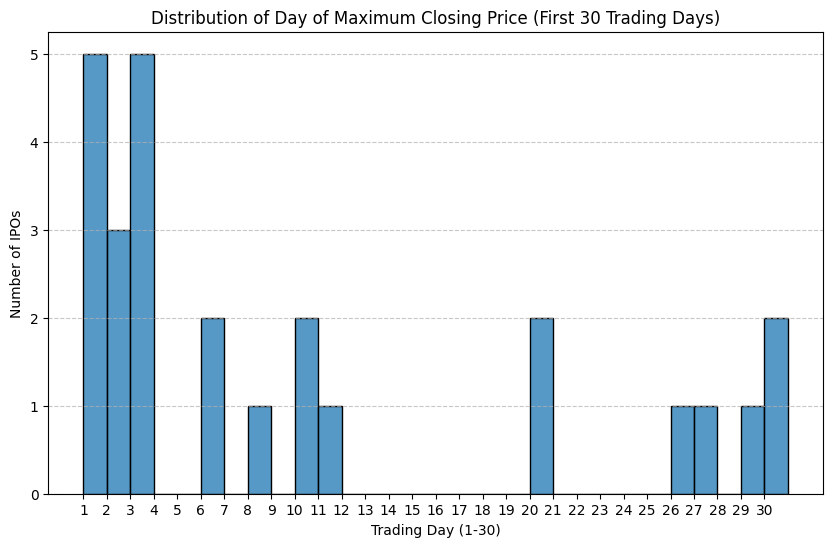

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# List to store the trading day index when max close was reached
max_close_day_indices = []

print(f"Analyzing day of max close within first 30 trading days for {len(filtered_df_ipo_price_returns)} stocks...")

for index, row in filtered_df_ipo_price_returns.iterrows():
    symbol = row['Symbol']
    first_trading_day_after_ipo = row['First_Trading_Day_After_IPO']

    try:
        effective_start_date = first_trading_day_after_ipo
        # Fetch data for a period long enough to cover at least 30 trading days
        end_fetch_date = effective_start_date + timedelta(days=60) # 60 calendar days should cover ~30 trading days

        ticker_data = yf.download(symbol,
                                  start=effective_start_date.strftime('%Y-%m-%d'),
                                  end=end_fetch_date.strftime('%Y-%m-%d'),
                                  interval="1d",
                                  progress=False,
                                  auto_adjust=False)

        # Explicit check for ticker_data *after* download, but before it can be used
        if not isinstance(ticker_data, pd.DataFrame):
            print(f"    ❌ yf.download for {symbol} returned a non-DataFrame object (Type: {type(ticker_data)}). Skipping.")
            continue # Skip to next IPO

        if ticker_data.empty or 'Adj Close' not in ticker_data.columns:
            print(f"    ❌ No valid historical stock data found for {symbol} from Yahoo Finance for max close day analysis (returned empty DataFrame or missing 'Adj Close'). Skipping.")
            continue # Skip to next IPO

        # Consider only the first 30 trading days available
        adj_closes = ticker_data['Adj Close'].iloc[:30]

        if not adj_closes.empty:
            # Find the index of the maximum value
            max_close_idx = adj_closes.idxmax()
            # Ensure max_close_idx is a scalar (Timestamp), not a Series, to avoid errors with get_loc
            if isinstance(max_close_idx, pd.Series):
                if not max_close_idx.empty:
                    max_close_idx = max_close_idx.iloc[0] # Take the first timestamp if idxmax returned a Series
                else:
                    print(f"    ⚠️ idxmax returned an empty Series for {symbol}. Skipping.")
                    continue

            # Convert the datetime index back to its position (0-based trading day)
            trading_day_of_max_close = adj_closes.index.get_loc(max_close_idx)
            max_close_day_indices.append(trading_day_of_max_close + 1) # +1 for 1-based trading day
        else:
            print(f"    ⚠️ No adjusted close data for {symbol} within first 30 trading days.")

    except Exception as e:
        # Enhanced error message to include the type of the exception
        print(f"    ❌ An unexpected error occurred while fetching data for {symbol} (Max Close Day analysis): {type(e).__name__} - {e}")

# Convert to DataFrame for easier plotting and analysis
max_close_df = pd.DataFrame(max_close_day_indices, columns=['Trading_Day_of_Max_Close'])

if not max_close_df.empty:
    print("\n--- Distribution of Day of Max Close within First 30 Trading Days ---")

    plt.figure(figsize=(10, 6))
    sns.histplot(max_close_df['Trading_Day_of_Max_Close'].dropna(), bins=range(1, 32), kde=False, stat='count')
    plt.title('Distribution of Day of Maximum Closing Price (First 30 Trading Days)')
    plt.xlabel('Trading Day (1-30)')
    plt.ylabel('Number of IPOs')
    plt.xticks(range(1, 31))
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()
else:
    print("\nNo data available to plot the distribution of the day of maximum closing price.")

### Day of Maximum Closing Price within First 30 Trading Days (All IPOs)

Now, let's extend the analysis to *all* IPOs in the `consolidated_df_with_deal_size` to find the trading day of their maximum closing price within the first 30 trading days. First, we'll calculate the `First_Trading_Day_After_IPO` for all stocks, and then use that to determine and visualize the peak day distribution.

In [18]:
# Create a copy of the consolidated DataFrame to work with
consolidated_df_all_ipo_data = consolidated_df_with_deal_size.copy()

# Ensure 'IPO Date' in consolidated_df_all_ipo_data is datetime type
consolidated_df_all_ipo_data['IPO Date'] = pd.to_datetime(consolidated_df_all_ipo_data['IPO Date'])

# Filter out IPOs that are in the future based on the current 'today' date
today = datetime.now().date() # Get only the date part of today
print(f"Current 'today' date used for filtering: {today}")

# Prepare list to store first trading days
all_next_trading_days = []

print(f"Calculating the first trading day after IPO for {len(consolidated_df_all_ipo_data)} stocks...")

for index, row in tqdm(consolidated_df_all_ipo_data.iterrows(), total=len(consolidated_df_all_ipo_data)):
    symbol = row['Symbol']
    ipo_date = row['IPO Date']

    # Start fetching data from the calendar day after IPO
    effective_start_date = ipo_date + timedelta(days=1)

    try:
        # Fetch data for a 15-calendar-day window to reliably find the actual first trading day
        ticker_data = yf.download(symbol,
                                  start=effective_start_date.strftime('%Y-%m-%d'),
                                  end=(effective_start_date + timedelta(days=15)).strftime('%Y-%m-%d'), # Check for next 15 calendar days
                                  interval="1d",
                                  progress=False,
                                  auto_adjust=False) # Explicitly set auto_adjust to False

        if not ticker_data.empty and 'Adj Close' in ticker_data.columns:
            # Select the minimum date from the downloaded dataset as the first trading day
            all_next_trading_days.append(ticker_data.index.min().normalize()) # Get just the date part
        else:
            all_next_trading_days.append(pd.NaT) # No trading data found
            #print(f"    ⚠️ Could not find trading data for {symbol} starting from {effective_start_date.strftime('%Y-%m-%d')} within 15 calendar days for First_Trading_Day_After_IPO.")

    except Exception as e:
        # Handle cases where yf.download itself might fail (e.g., invalid symbol)
        all_next_trading_days.append(pd.NaT)
        print(f"    ❌ Error determining next trading day for {symbol} after {ipo_date.strftime('%Y-%m-%d')}: {e}")

consolidated_df_all_ipo_data['First_Trading_Day_After_IPO'] = all_next_trading_days

# Filter out any IPOs that don't have a valid first trading day after IPO
consolidated_df_all_ipo_data = consolidated_df_all_ipo_data[consolidated_df_all_ipo_data['First_Trading_Day_After_IPO'].notna()].copy()

print("\n--- Consolidated DataFrame with First Trading Day After IPO (Head) ---")
display(consolidated_df_all_ipo_data[['Symbol', 'IPO Date', 'Deal Size', 'First_Trading_Day_After_IPO']].head())

print("\n--- Consolidated DataFrame with First Trading Day After IPO (Tail) ---")
display(consolidated_df_all_ipo_data[['Symbol', 'IPO Date', 'Deal Size', 'First_Trading_Day_After_IPO']].tail())

Current 'today' date used for filtering: 2026-07-15
Calculating the first trading day after IPO for 771 stocks...


  0%|          | 0/771 [00:00<?, ?it/s]

ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['TDAC']: YFPricesMissingError('possibly delisted; no price data found  (1d 2024-12-24 -> 2025-01-08) (Yahoo error = "Data doesn\'t exist for startDate = 1735016400, endDate = 1736312400")')
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['RANG']: YFPricesMissingError('possibly delisted; no price data found  (1d 2024-12-21 -> 2025-01-05) (Yahoo error = "Data doesn\'t exist for startDate = 1734757200, endDate = 1736053200")')
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['DRDB']: YFPricesMissingError('possibly delisted; no price data found  (1d 2024-12-14 -> 2024-12-29) (Yahoo error = "Data doesn\'t exist for startDate = 1734152400, endDate = 1735448400")')
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['MLAC']: YFPricesMissingError('possibly delisted; no price data found  (1d 2024-12-14 -> 2024-12-29) (Yahoo error = "Data doesn\'t exist for startDate = 1734152400, endDate = 1735448400")')
ERROR:yfinance:
1 Failed download:
E


--- Consolidated DataFrame with First Trading Day After IPO (Head) ---


,Symbol,IPO Date,Deal Size,First_Trading_Day_After_IPO
0,ONEG,2024-12-31,7.00M,2025-01-02
1,BYAH,2024-12-27,-,2024-12-30
2,HIT,2024-12-23,9.20M,2024-12-24
5,YAAS,2024-12-20,10.35M,2024-12-23
6,LSE,2024-12-19,5.50M,2024-12-20



--- Consolidated DataFrame with First Trading Day After IPO (Tail) ---


,Symbol,IPO Date,Deal Size,First_Trading_Day_After_IPO
754,HLXC,2026-01-23,125.00M,2026-01-26
758,BTGO,2026-01-22,212.79M,2026-01-23
763,GCDT,2026-01-13,10.00M,2026-01-14
764,AKTS,2026-01-09,317.70M,2026-01-12
767,BUDA,2026-01-08,20.00M,2026-01-09


Analyzing day of max close within first 30 trading days for 455 stocks...


  0%|          | 0/455 [00:00<?, ?it/s]


--- Distribution of Day of Max Close within First 30 Trading Days (All IPOs) ---


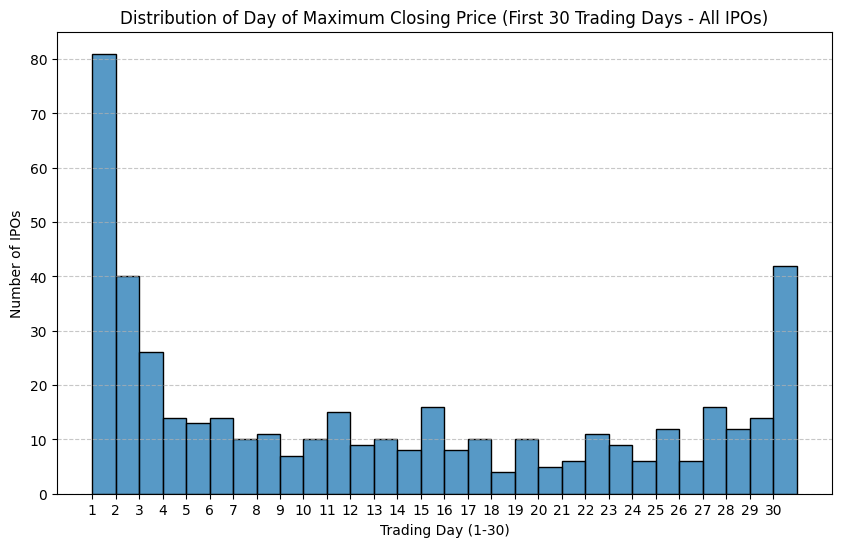

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# List to store the trading day index when max close was reached
max_close_day_indices_all = []

print(f"Analyzing day of max close within first 30 trading days for {len(consolidated_df_all_ipo_data)} stocks...")

for index, row in tqdm(consolidated_df_all_ipo_data.iterrows(), total=len(consolidated_df_all_ipo_data)):
    symbol = row['Symbol']
    first_trading_day_after_ipo = row['First_Trading_Day_After_IPO']

    try:
        effective_start_date = first_trading_day_after_ipo
        # Fetch data for a period long enough to cover at least 30 trading days
        end_fetch_date = effective_start_date + timedelta(days=60) # 60 calendar days should cover ~30 trading days

        ticker_data = yf.download(symbol,
                                  start=effective_start_date.strftime('%Y-%m-%d'),
                                  end=end_fetch_date.strftime('%Y-%m-%d'),
                                  interval="1d",
                                  progress=False,
                                  auto_adjust=False)

        if not isinstance(ticker_data, pd.DataFrame):
            #print(f"    ❌ yf.download for {symbol} returned a non-DataFrame object (Type: {type(ticker_data)}). Skipping.")
            continue # Skip to next IPO

        if ticker_data.empty or 'Adj Close' not in ticker_data.columns:
            #print(f"    ❌ No valid historical stock data found for {symbol} from Yahoo Finance for max close day analysis (returned empty DataFrame or missing 'Adj Close'). Skipping.")
            continue # Skip to next IPO

        # Consider only the first 30 trading days available
        adj_closes = ticker_data['Adj Close'].iloc[:30]

        if not adj_closes.empty:
            max_close_idx = adj_closes.idxmax()
            if isinstance(max_close_idx, pd.Series):
                if not max_close_idx.empty:
                    max_close_idx = max_close_idx.iloc[0] # Take the first timestamp if idxmax returned a Series
                else:
                    #print(f"    ⚠️ idxmax returned an empty Series for {symbol}. Skipping.")
                    continue

            trading_day_of_max_close = adj_closes.index.get_loc(max_close_idx)
            max_close_day_indices_all.append(trading_day_of_max_close + 1) # +1 for 1-based trading day
        else:
            #print(f"    ⚠️ No adjusted close data for {symbol} within first 30 trading days.")
            pass # Suppress warning for many entries

    except Exception as e:
        #print(f"    ❌ An unexpected error occurred while fetching data for {symbol} (Max Close Day analysis): {type(e).__name__} - {e}")
        pass # Suppress error for many entries

# Convert to DataFrame for easier plotting and analysis
max_close_df_all = pd.DataFrame(max_close_day_indices_all, columns=['Trading_Day_of_Max_Close'])

if not max_close_df_all.empty:
    print("\n--- Distribution of Day of Max Close within First 30 Trading Days (All IPOs) ---")

    plt.figure(figsize=(10, 6))
    sns.histplot(max_close_df_all['Trading_Day_of_Max_Close'].dropna(), bins=range(1, 32), kde=False, stat='count')
    plt.title('Distribution of Day of Maximum Closing Price (First 30 Trading Days - All IPOs)')
    plt.xlabel('Trading Day (1-30)')
    plt.ylabel('Number of IPOs')
    plt.xticks(range(1, 31))
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()
else:
    print("\nNo data available to plot the distribution of the day of maximum closing price for all IPOs.")